# LPHY1365: Météorologie


## Chapitre 6: Rappels et notions complémentaires de mécanique

Source: *Triplet, J.-P., & Roche, G.* (1996). Météorologie générale. Service central de la communication et de la commercialisation de Météo-France.


Le point de départ de cette première session est une image représentant la péninsule ibérique le 17 septembre 2024, alors que le centre du Portugal est soumis à des feux de forêt d'une ampleur considérable.


Mais cette photo est-elle bien réelle? Alors que les intelligences artificielles génératives inondent le web de contenu créé de toutes pièces, pourquoi cette image ne serait-elle pas, elle aussi, une construction virtuelle? 

*Questions pour les étudiant.e.s:*
- Quels sont les indices qui permettraient de vérifier l'authenticité de l'image ou de démontrer son inauthenticité?
- D'où provient l'image? 
- La source est-elle fiable?
- Les trajectoires suivies par la fumée de combustion sont-elles alignées aux vents du jour?

<!--Chargement de l'image satellite montrant les feux au Portugal le 17 septembre 2024-->


![image](téléchargement.jpeg)

Source: https://atmosphere.copernicus.eu/wildfires-rage-across-northern-portugal-cams-tracks-their-impacts (consultée la dernière fois le 11 février 2026)

In [41]:
# Chargement du fichier netcdf portant le doux nom de "617b904f234593921f174fa06a177d56.nc" qui a été téléchargé depuis
# le site de la réanalyse ERA5. Importation des bibliothèques nécessaires pour manipuler les données et les visualiser.
# Ensuite, plot du champ de vent à 10 mètres d'altitude pour 12.00UTC au 17 septembre 2024.

import xarray as xr
import matplotlib.pyplot as plt
# Charger le fichier netcdf
ds = xr.open_dataset('./data/617b904f234593921f174fa06a177d56.nc')
# Afficher les variables disponibles pour vérifier que nous avons les données de vent à 10 mètres
print(ds)

# Prendre le temps d'examiner le nom des variables, dont la variables temporelle, pour s'assurer que nous sélectionnons les bonnes données. 
# Imprimer les dimensions du dataset pour comprendre la structure des données et identifier les variables de vent à 10 mètres.
print(ds.dims)


<xarray.Dataset>
Dimensions:     (valid_time: 24, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2024-09-17 ... 2024-09-17T23:00:00
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) object ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 ...
    v10         (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-08T13:54 GRIB to CDM+CF via cfgrib-0.9.1...
Frozen({'valid_time': 24, 'latitude': 721, 'longitude': 1440})


In [42]:
# La dimension "temps" s'appelle donc "valid_time". Nous allons sélectionner les données de vent à 10 mètres d'altitude pour le 17 septembre 2024 à 12.00UTC.
# Sélectionner les données de vent à 10 mètres d'altitude pour le 17 septembre 2024 à 12.00UTC

# Convertir la date et l'heure en format compatible avec xarray
time_selection = '2024-09-17T12:00:00'
# Sélectionner les données de vent à 10 mètres d'altitude pour le temps spécifié
u10 = ds['u10'].sel(valid_time=time_selection)
v10 = ds['v10'].sel(valid_time=time_selection)
# Afficher les données sélectionnées pour vérifier qu'elles sont correctes
print(u10)
print(v10)
plt.show()

<xarray.DataArray 'u10' (latitude: 721, longitude: 1440)>
[1038240 values with dtype=float32]
Coordinates:
    number      int64 ...
    valid_time  datetime64[ns] 2024-09-17T12:00:00
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      object ...
Attributes: (12/32)
    GRIB_paramId:                             165
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                10 metre U wind component
    units:                                    m s**-1
    standard_name:        

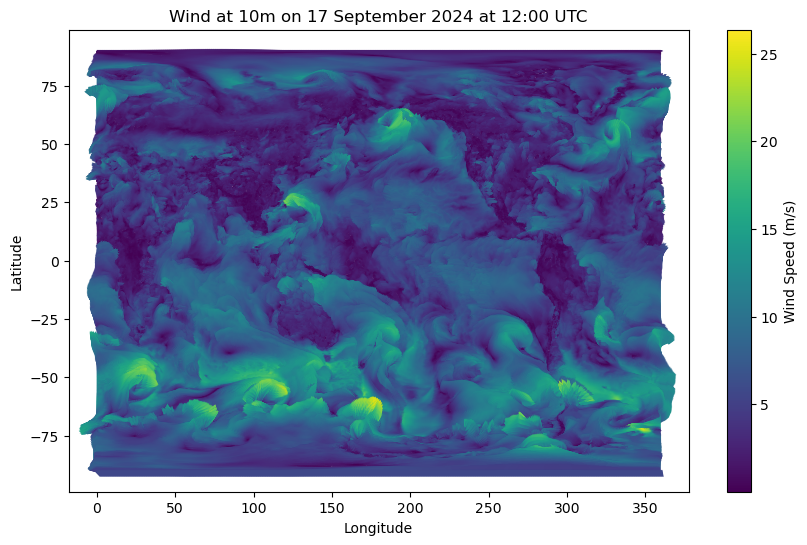

In [43]:
# Plot du champ de vent à 10 mètres par des flèches (quiver plot) pour visualiser la direction du vent.
# Nous choisissons en plus de créer un champ scalaire "wind speed" qui est la norme du vent. Les flèches
# auront une longueur identique et le fond de carte sera coloré en fonction de la vitesse du vent.
import numpy as np
# Calculer la vitesse du vent à partir des composantes u et v
wind_speed = np.sqrt(u10**2 + v10**2)
# Créer une grille de coordonnées pour le plot
lon = ds['longitude']
lat = ds['latitude']
# Créer un quiver plot pour les composantes du vent
plt.figure(figsize=(10, 6))
plt.quiver(lon, lat, u10, v10, wind_speed, scale=500, cmap='viridis')
plt.colorbar(label='Wind Speed (m/s)')
plt.title('Wind at 10m on 17 September 2024 at 12:00 UTC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'lonlat'
  result = super().contourf(*args, **kwargs)


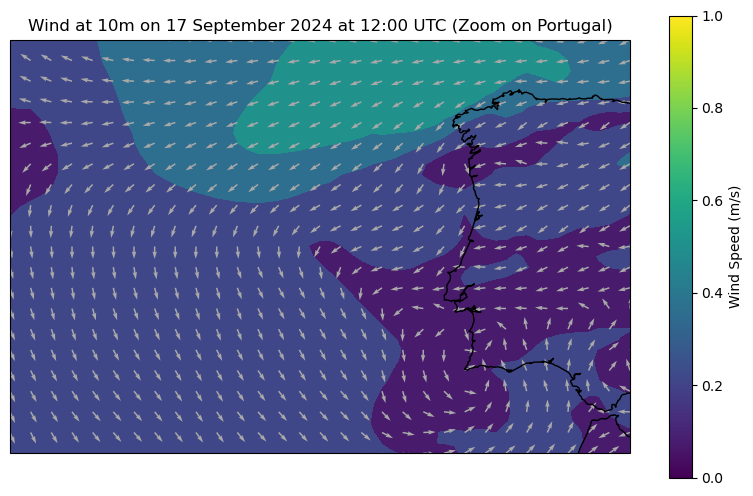

In [44]:
# Tout ça a une bonne tête. Faison maintenant un "zoom" sur le Portugal, qui est la zone qui nous intéresse.
# Définir les limites de la zone d'intérêt (Portugal)
lon_min, lon_max = -20, -5
lat_min, lat_max = 35, 45

# Créer un jeu de données "zoomé" pour la zone d'intérêt
u10_zoom = u10.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
v10_zoom = v10.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
wind_speed_zoom = wind_speed.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
lon_zoom = lon.sel(longitude=slice(lon_min, lon_max))
lat_zoom = lat.sel(latitude=slice(lat_min, lat_max))

# Créer un quiver plot pour la zone d'intérêt. Nous utilisont maintenant Cartopy pour ajouter une carte de fond.
# Importation de la lbriéthèque Cartopy pour la visualisation cartographique
plt.figure(figsize=(10, 6))
import cartopy.crs as ccrs

# Création du fond de carte avec Cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
# Ajouter les flèches de vent
plt.contourf(lon, lat, wind_speed, lonlat=True, cmap='viridis')
# normalize to get equal length arrows. plot arrows in dark grey and plot only every second arrow to avoid overcrowding
declutter = 2
plt.quiver(lon[ ::declutter], lat[::declutter], u10[::declutter, ::declutter] / wind_speed[::declutter, ::declutter], v10[::declutter, ::declutter] / wind_speed[::declutter, ::declutter], scale=50, color='darkgrey')
plt.colorbar(label='Wind Speed (m/s)')
plt.title('Wind at 10m on 17 September 2024 at 12:00 UTC (Zoom on Portugal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


## 6.1 - Quelques éléments de cinématique


Considérons une particule **ponctuelle** et intéressons-nous à son mouvement, décrit par une courbe $C$.

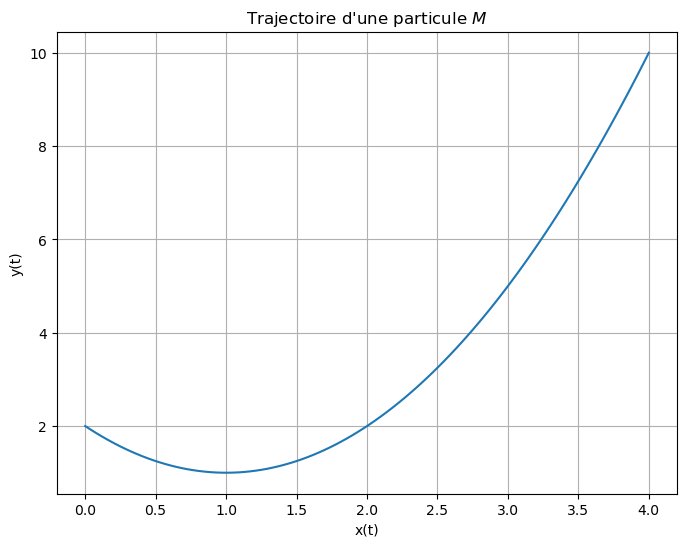

In [63]:
# Création d'un graphe bi-dimensionnel (axes x et y) décrivant la trajectoire d'une particule M (choisie ici comme une courbe paramétrée par le temps x(t) = t et y(t) = (t-1)^2 + 1
import numpy as np
import matplotlib.pyplot as plt
# Définir la fonction de la trajectoire
def trajectory(t):
    x = t
    y = (t - 1)**2 + 1
    return x, y
# Générer des points de temps pour tracer la trajectoire
t_values = np.linspace(0, 4, 100)
x_values, y_values = trajectory(t_values)
# Tracer la trajectoire
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label='Trajectoire de M')
plt.title('Trajectoire d\'une particule $M$')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.grid()
plt.show()


On appelle $M_0$ le point de la trajectoire correspondant au temps initial $t=0$. 

<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
/var/folders/m3/rlnbxzw916zg5rxbzlfc01h40000gq/T/ipykernel_79840/1174704439.py:13: SyntaxWarning: invalid escape sequence '\D'
  plt.scatter(Md[0], Md[1], 100, color='green', label='Particule au temps $t + \Delta t$', zorder=5)  # zorder pour mettre le point au-dessus de la trajectoire


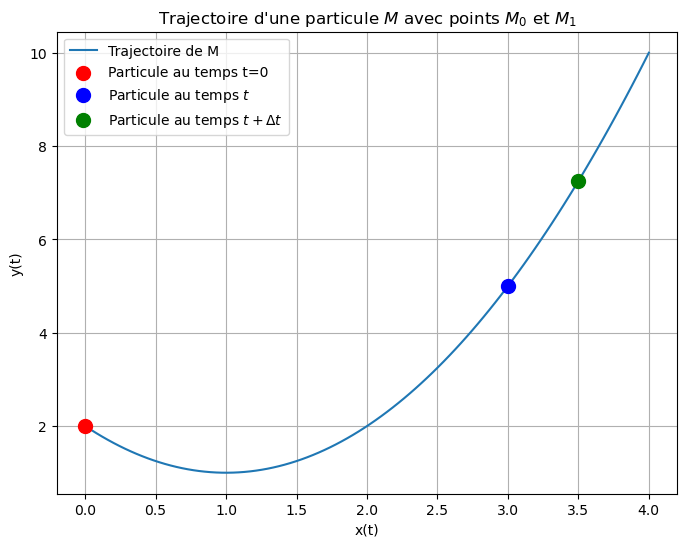

In [ ]:
# Ajout sur le graphe du point M0 correspondant à t=0, et ajouter sur le graphe un point arbitraire (x,y)
# (choisi ici comme correspondant à t = 1)
t0 = 0
M0 = trajectory(t0)
tt = 3 # pour désigner la variable courante t
ttpD = 3.5 # Pour tt + delta t
M = trajectory(tt)     
Md = trajectory(ttpD)
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label='Trajectoire de M')
plt.scatter(M0[0], M0[1], 100, color='red', label='Particule au temps t=0', zorder=5)  # zorder pour mettre le point au-dessus de la trajectoire
plt.scatter(M[0], M[1], 100, color='blue', label='Particule au temps $t$', zorder=5)  # zorder pour mettre le point au-dessus de la trajectoire
plt.scatter(Md[0], Md[1], 100, color='green', label='Particule au temps $t + \Delta t$', zorder=5)  # zorder pour mettre le point au-dessus de la trajectoire
plt.title('Trajectoire d\'une particule $M$ avec points $M_0$ et $M_1$')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.grid()
plt.legend()
# Mettre les axes en arrière plan pour que le point M0 soit bien visible
plt.gca().set_axisbelow(True)
plt.show()

In [ ]:
plt.title('Trajectoire d\'une particule $M$ avec points $M_0$ et $M_1$')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.grid()
plt.legend()
# Mettre les axes en arrière plan pour que le point M0 soit bien visible
plt.gca().set_axisbelow(True)
plt.show()

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Function to update the plot
def update(x):
    plt.figure(figsize=(6,4))
    
    # Create curve
    t = np.linspace(0, 10, 400)
    y = np.sin(t)
    plt.plot(t, y)
    
    # Moving point
    plt.scatter(x, np.sin(x), color='red', s=100)
    
    plt.xlim(0, 10)
    plt.ylim(-1.5, 1.5)
    plt.grid()
    plt.show()

# Slider
interact(update, x=(0, 10, 0.1))


interactive(children=(FloatSlider(value=5.0, description='x', max=10.0), Output()), _dom_classes=('widget-inte…

<function __main__.update(x)>